In [1]:
###################################### imports
from datetime import datetime
import math
import time
import resource
import os
import re
import numpy as np
import pandas as pd
from pyprojroot import here
import matplotlib.pyplot as plt
###################################### constants
DIR_MMSEQS = here() / 'data/mmseqs_clusters/'

###################################### data loading
fps_clust = list(DIR_MMSEQS.rglob('*clusters_id0*'))
list_dfs = []

for fp in fps_clust:
    df = pd.read_csv(fp, sep='\t', header=None, names=['representative', 'member'])
    origin = fp.stem.replace('_clusters_id0', '')
    df['origin'] = origin
    cluster_stats = df.groupby('representative').size().reset_index(name='member_count')
    cluster_stats = cluster_stats.sort_values(
        by=['member_count', 'representative'], 
        ascending=[False, True]
    ).reset_index(drop=True)
    cluster_stats['cluster_rank'] = cluster_stats.index + 1
    df = df.merge(cluster_stats, on='representative')
    df = df.sort_values(by=['cluster_rank', 'member']).reset_index(drop=True)
    df = df[['representative', 'member', 'origin', 'member_count', 'cluster_rank']]
    df[['label', 'percent_id']] = df['origin'].str.split('_', n=1, expand=True)
    list_dfs.append(df)
print(f"{'.'*40}")
print("[MMSeqs2 clustering (all sequences redundant)]\n")

if list_dfs:
    clus_df = pd.concat(list_dfs, ignore_index=True)
    print(clus_df.head(10))
    print(f"{'.'*10}")
    print(clus_df.tail(10))
    print(f"{'.'*40}")
    print(clus_df['origin'].unique())
else:
    print("No cluster files found.")


........................................
[MMSeqs2 clustering (all sequences redundant)]

  representative  member            origin  member_count  cluster_rank  \
0         Q6P461  P0C7M7  mitochondrion_40             7             1   
1         Q6P461  Q08AH1  mitochondrion_40             7             1   
2         Q6P461  Q08AH3  mitochondrion_40             7             1   
3         Q6P461  Q53FZ2  mitochondrion_40             7             1   
4         Q6P461  Q68CK6  mitochondrion_40             7             1   
5         Q6P461  Q6NUN0  mitochondrion_40             7             1   
6         Q6P461  Q6P461  mitochondrion_40             7             1   
7         P12236  P05141  mitochondrion_40             4             2   
8         P12236  P12235  mitochondrion_40             4             2   
9         P12236  P12236  mitochondrion_40             4             2   

           label percent_id  
0  mitochondrion         40  
1  mitochondrion         40  
2  mit

In [2]:
def print_unique_summary(df: pd.DataFrame) -> None:
    """
    Prints the number of unique values and the first 5 unique elements 
    for every column in a pandas DataFrame.
    """
    for col in df.columns:
        unique_vals = df[col].unique()
        num_unique = len(unique_vals)
        first_five = unique_vals[:5].tolist() # tolist() for cleaner console output
        
        print(f"Column: '{col}'")
        print(f"  - Unique count: {num_unique}")
        print(f"  - First 5 unique: {first_five}")
        print("-" * 40)

print_unique_summary(clus_df)

Column: 'representative'
  - Unique count: 12915
  - First 5 unique: ['Q6P461', 'P12236', 'P17612', 'P24310', 'Q15118']
----------------------------------------
Column: 'member'
  - Unique count: 13078
  - First 5 unique: ['P0C7M7', 'Q08AH1', 'Q08AH3', 'Q53FZ2', 'Q68CK6']
----------------------------------------
Column: 'origin'
  - Unique count: 102
  - First 5 unique: ['mitochondrion_40', 'mitochondrion_45', 'mitochondrion_70', 'mitochondrion_85', 'mitochondrion_65']
----------------------------------------
Column: 'member_count'
  - Unique count: 60
  - First 5 unique: [7, 4, 3, 2, 1]
----------------------------------------
Column: 'cluster_rank'
  - Unique count: 5752
  - First 5 unique: [1, 2, 3, 4, 5]
----------------------------------------
Column: 'label'
  - Unique count: 6
  - First 5 unique: ['mitochondrion', 'ER', 'secreted', 'cytoplasm', 'nucleus']
----------------------------------------
Column: 'percent_id'
  - Unique count: 17
  - First 5 unique: ['40', '45', '70', '85

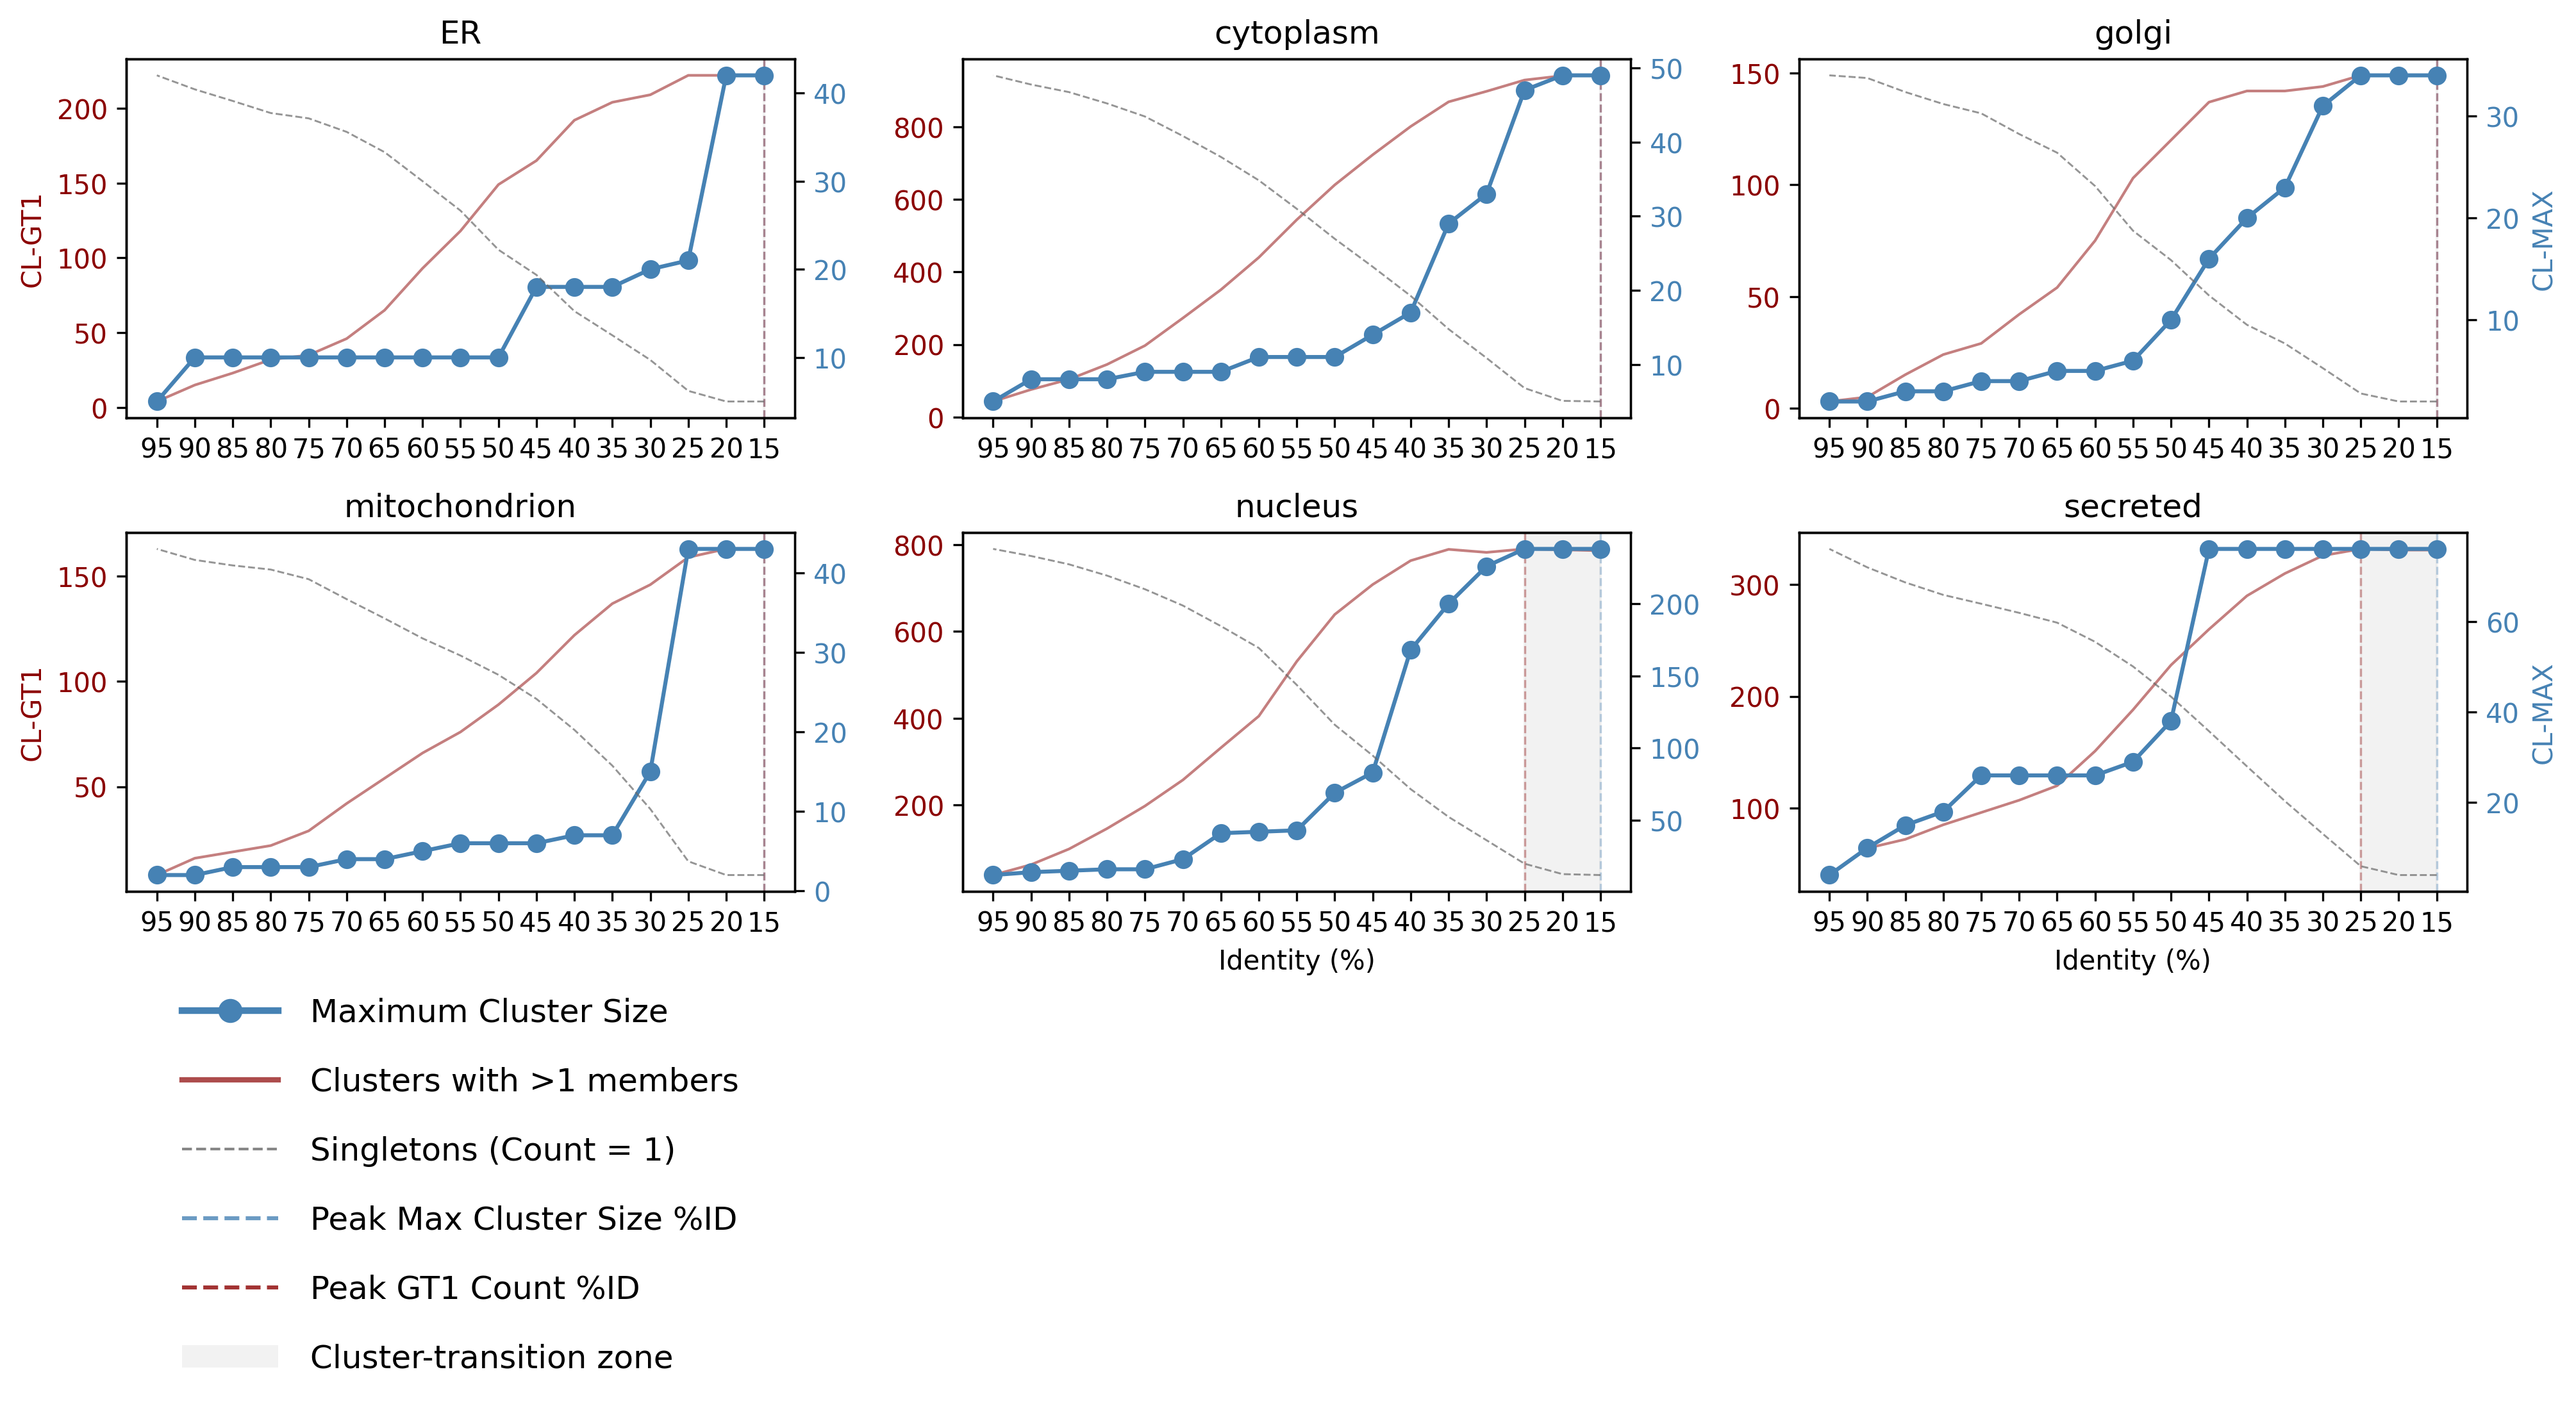

In [3]:
#!/usr/bin/env python3
"""Plot cluster size and count metrics per label with configurable axis titles and peak reference lines."""

import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

###################################### PARAMS
SHOW_LINES = True
PLOT_DPI = 300
PLOT_W = 4.5
PLOT_H = 2.5
N_COLS = 3
MAIN_COLOR = 'steelblue'
LINE_COLOR = 'darkred'
SINGLETON_COLOR = 'dimgray'
LIGHT_GRAY = 'lightgray'
SHADE_COLOR = 'gainsboro'

X_LABEL_TEXT = 'Identity (%)'
Y_LEFT_LABEL_TEXT = 'CL-GT1'
Y_RIGHT_LABEL_TEXT = 'CL-MAX'
LEGEND_MAIN_TEXT = 'Maximum Cluster Size'
LEGEND_LINE_TEXT = 'Clusters with >1 members'
LEGEND_SINGLETON_TEXT = 'Singletons (Count = 1)'
LEGEND_PEAK_MAIN_TEXT = 'Peak Max Cluster Size %ID'
LEGEND_PEAK_LINE_TEXT = 'Peak GT1 Count %ID'
LEGEND_SHADE_TEXT = 'Cluster-transition zone'

plt.rcParams['figure.dpi'] = PLOT_DPI

SPECIFIED_ORDER = [
    'aegypti', 'albopictus', 'japonicus',
    'aedes']

# Define custom titles corresponding to your specified order (falls back to label if missing)
CUSTOM_TITLES = {
    'union': 'E. coli',
    'k12': 'K12',
}

###################################### EXECUTION
clus_df['percent_id'] = pd.to_numeric(clus_df['percent_id'])
df_u = clus_df[['label', 'percent_id', 'cluster_rank', 'member_count']].drop_duplicates()

df_max = df_u.groupby(['label', 'percent_id'])['member_count'].max().rename('max_size')
df_gt1 = df_u[df_u['member_count'] > 1].groupby(['label', 'percent_id']).size().rename('gt1_count')
df_eq1 = df_u[df_u['member_count'] == 1].groupby(['label', 'percent_id']).size().rename('eq1_count')

df_agg = pd.concat([df_max, df_gt1, df_eq1], axis=1).fillna(0).reset_index()

existing_labels = set(df_agg['label'].unique())
labels = [lbl for lbl in SPECIFIED_ORDER if lbl in existing_labels] + [
    lbl for lbl in df_agg['label'].unique() if lbl not in set(SPECIFIED_ORDER)
]

all_xticks = sorted(df_agg['percent_id'].unique())

# FIX: Always reserve 1 dedicated panel slot for the legend regardless of label count
total_panels = len(labels) + 1 
n_rows = (total_panels + N_COLS - 1) // N_COLS

fig, axes = plt.subplots(n_rows, N_COLS, figsize=(N_COLS * PLOT_W, n_rows * PLOT_H))
axes = axes.flatten()

for i, lbl in enumerate(labels):
    sub = df_agg[df_agg['label'] == lbl].sort_values('percent_id')
    
    if SHOW_LINES:
        max_size_pid = sub.loc[sub['max_size'].idxmax(), 'percent_id']
        max_gt1_pid = sub.loc[sub['gt1_count'].idxmax(), 'percent_id']
        left_pid, right_pid = min(max_size_pid, max_gt1_pid), max(max_size_pid, max_gt1_pid)
        axes[i].axvspan(left_pid, right_pid, color=SHADE_COLOR, alpha=0.35, zorder=0)
        axes[i].axvline(max_size_pid, color=MAIN_COLOR, linestyle='--', linewidth=0.8, alpha=0.35, zorder=1)
        axes[i].axvline(max_gt1_pid, color=LINE_COLOR, linestyle='--', linewidth=0.8, alpha=0.35, zorder=1)

    # GT1 count (left y-axis)
    axes[i].plot(sub['percent_id'], sub['gt1_count'], color=LINE_COLOR, linewidth=1.0, alpha=0.5, zorder=2)
    
    # Set custom title using the dictionary lookup
    panel_title = CUSTOM_TITLES.get(lbl, lbl)
    axes[i].set_title(panel_title)
    
    axes[i].set_xticks(all_xticks)
    axes[i].tick_params(axis='y', labelcolor=LINE_COLOR)
    axes[i].invert_xaxis()
    
    if i >= total_panels - N_COLS:
        axes[i].set_xlabel(X_LABEL_TEXT)
        
    if i % N_COLS == 0:
        axes[i].set_ylabel(Y_LEFT_LABEL_TEXT, color=LINE_COLOR)

    # Max size (first right twin axis)
    ax2 = axes[i].twinx()
    ax2.plot(sub['percent_id'], sub['max_size'], color=MAIN_COLOR, marker='o', linestyle='-', linewidth=1.5, zorder=3)
    ax2.tick_params(axis='y', labelcolor=MAIN_COLOR)
    
    is_rightmost_col = (i + 1) % N_COLS == 0
    is_last_data_plot = (i == len(labels) - 1)
    if is_rightmost_col or is_last_data_plot:
        ax2.set_ylabel(Y_RIGHT_LABEL_TEXT, color=MAIN_COLOR)

    # Singletons / eq1 count (second twin axis, independent scale, no y shown)
    ax3 = axes[i].twinx()
    ax3.plot(sub['percent_id'], sub['eq1_count'], color=SINGLETON_COLOR, linestyle='--', linewidth=0.7, alpha=0.7, zorder=2.5)
    ax3.set_yticks([])
    ax3.spines['right'].set_visible(False)

# Dedicated Legend Panel Assignment
legend_idx = len(labels)
legend_ax = axes[legend_idx]
legend_ax.axis('off')

legend_elements = [
    Line2D([0], [0], color=MAIN_COLOR, marker='o', markersize=8, linewidth=2.5, label=LEGEND_MAIN_TEXT),
    Line2D([0], [0], color=LINE_COLOR, linewidth=2.0, alpha=0.7, label=LEGEND_LINE_TEXT),
    Line2D([0], [0], color=SINGLETON_COLOR, linestyle='--', linewidth=1.0, alpha=0.8, label=LEGEND_SINGLETON_TEXT),
]
if SHOW_LINES:
    legend_elements.extend([
        Line2D([0], [0], color=MAIN_COLOR, linestyle='--', linewidth=1.5, alpha=0.8, label=LEGEND_PEAK_MAIN_TEXT),
        Line2D([0], [0], color=LINE_COLOR, linestyle='--', linewidth=1.5, alpha=0.8, label=LEGEND_PEAK_LINE_TEXT),
        Patch(facecolor=SHADE_COLOR, alpha=0.35, edgecolor='none', label=LEGEND_SHADE_TEXT),
    ])

legend_ax.legend(
    handles=legend_elements, 
    loc='center', 
    frameon=False, 
    fontsize=12, 
    labelspacing=1.2, 
    handlelength=3.0,
    handletextpad=1.0
)

# Clean up any leftover empty axes slots in the grid
for j in range(legend_idx + 1, len(axes)): 
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()